In [35]:
# train_terramind_radar.py
import os
import pickle
from typing import List, Dict, Any, Optional

from matplotlib import backend_bases
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import numpy as np

# terratorch registry
from terratorch import BACKBONE_REGISTRY

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


In [36]:
# ---------------------------
# ========== 1) Dataset =====
# ---------------------------
class PickleRadarDEM_Dataset(Dataset):
    
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    def __init__(self, samples):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def _process_radar(self, radar_patch):
        """Process radar: NaN → normalize → max Z → upsample"""
        radar_arr = radar_patch.copy()
        
        radar_arr[radar_arr == -9999.0] = self.DBZ_MIN
        radar_arr = np.where(np.isnan(radar_arr), self.DBZ_MIN, radar_arr)
        
        radar_arr = (radar_arr - self.DBZ_MIN) / (self.DBZ_MAX - self.DBZ_MIN)
        radar_arr = np.clip(radar_arr, 0, 1)
        
        radar_t = torch.from_numpy(radar_arr).float()
        radar_maxz, _ = torch.max(radar_t, dim=1)
        
        radar_up = F.interpolate(
            radar_maxz.unsqueeze(0),
            size=(256, 256),
            mode='nearest',
        ).squeeze(0)
        
        if torch.isnan(radar_up).any():
            radar_up = torch.nan_to_num(radar_up, nan=0.0)
        
        return radar_up  # (12, 256, 256)
    
    def _process_dem(self, dem_patch):
        """Process DEM: NaN → center crop to 256×256"""
        dem_arr = dem_patch.copy()
        
        if dem_arr.ndim == 2:
            dem_arr = dem_arr[np.newaxis, :, :]
        
        dem_arr = np.where(np.isnan(dem_arr), 0.0, dem_arr)
        dem_t = torch.from_numpy(dem_arr).float()
        
        # Center crop 264→256
        if dem_t.shape[-1] == 264:
            dem_t = dem_t[:, 4:260, 4:260]
        elif dem_t.shape[-1] != 256:
            dem_t = F.interpolate(
                dem_t.unsqueeze(0), 
                size=(256, 256), 
                mode='bilinear', 
                align_corners=False
            ).squeeze(0)
        
        return dem_t  # (1, 256, 256)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        
        radar_t = self._process_radar(s.get("radar_patch"))
        dem_t = self._process_dem(s.get("dem_patch"))
        
        return {
            'radar_patch': radar_t,
            'dem_patch': dem_t,
            'target': torch.tensor(s['hourly_precip_mm'], dtype=torch.float32),
            'gauge_pixel': (2, 2),
            'station_name': s.get('station_name', 'unknown')
        }

In [37]:
# ---------------------------
# ====== 3) Fusion + Head ==
# ---------------------------

class SpatialPrecipitationDecoder(nn.Module):
    """
    Decodes spatial features to a 5×5 precipitation map.
    Preserves spatial structure throughout.
    """
    def __init__(self, in_channels=192, target_size=5):
        super().__init__()
        
        # Assuming TerraMind outputs (batch, 192, H, W) where H,W ~= 16
        # We need to downsample to 5×5
        
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        
        # Final conv to 1 channel (precipitation)
        self.conv_out = nn.Conv2d(32, 1, kernel_size=1)
        
        # Adaptive pooling to exactly 5×5
        self.final_pool = nn.AdaptiveAvgPool2d((target_size, target_size))
        
    def forward(self, x):
        """
        Input: (batch, in_channels, H, W) - spatial features
        Output: (batch, 5, 5) - precipitation map
        """
        # x shape: (8, 192, 16, 16) for example
        
        x = F.relu(self.bn1(self.conv1(x)))  # (8, 128, 16, 16)
        x = F.relu(self.bn2(self.conv2(x)))  # (8, 64, 16, 16)
        x = F.relu(self.bn3(self.conv3(x)))  # (8, 32, 16, 16)
        
        x = self.conv_out(x)  # (8, 1, 16, 16)
        
        # Downsample to exactly 5×5
        x = self.final_pool(x)  # (8, 1, 5, 5)
        
        # Remove channel dimension: (8, 1, 5, 5) → (8, 5, 5)
        x = x.squeeze(1)
        
        return x


In [38]:
# ---------------------------
# === 4) Terramind wrapper ==
# ---------------------------

class TerraMindRainModel(pl.LightningModule):
    def __init__(
        self,
        backbone_name: str = "terramind_v1_tiny",
        lr: float = 1e-4,
        grid_size: int = 5
    ):
        super().__init__()
        self.save_hyperparameters()
        
        print("Building TerraMind encoder...")
        self.backbone = BACKBONE_REGISTRY.build(
            backbone_name,
            pretrained=True,
            modalities=["DEM", {"RADAR": 12}]
        )
        
        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        num_frozen = sum(p.numel() for p in self.backbone.parameters())
        print(f"✓ TerraMind encoder frozen ({num_frozen:,} parameters)")
        
        # Set backbone to eval mode
        self.backbone.eval()
        
        # Infer output dimensions
        with torch.no_grad():
            dummy_input = {
                "DEM": torch.zeros(1, 1, 256, 256),
                "RADAR": torch.zeros(1, 12, 256, 256)
            }
            encoder_output = self.backbone(dummy_input)
            
            if isinstance(encoder_output, list):
                features = encoder_output[-1]
            elif isinstance(encoder_output, dict):
                features = list(encoder_output.values())[0]
            else:
                features = encoder_output
            
            if features.dim() == 3:
                in_channels = features.shape[2]
            elif features.dim() == 4:
                in_channels = features.shape[1]
            else:
                in_channels = features.shape[-1]
        
        print(f"TerraMind output: {in_channels} feature channels")
        
        # Decoder
        self.decoder = SpatialPrecipitationDecoder(
            in_channels=in_channels,
            target_size=grid_size
        )
        
        num_trainable = sum(p.numel() for p in self.decoder.parameters())
        print(f"✓ Decoder created ({num_trainable:,} trainable parameters)")
        
        self.criterion = nn.MSELoss()
        self.lr = lr
    
    # === THIS METHOD MUST BE AT CLASS LEVEL (same indent as __init__) ===
    def train(self, mode=True):
        """Override train to keep backbone in eval mode."""
        super().train(mode)
        self.backbone.eval()  # Always keep backbone in eval
        return self
    
    def forward(self, batch):
        encoder_input = {
            "DEM": batch["dem_patch"],
            "RADAR": batch["radar_patch"]
        }
        
        encoder_output = self.backbone(encoder_input)
        
        if isinstance(encoder_output, list):
            features = encoder_output[-1]
        elif isinstance(encoder_output, dict):
            features = list(encoder_output.values())[0]
        else:
            features = encoder_output
        
        if features.dim() == 3:
            batch_size, num_patches, feat_dim = features.shape
            H = W = int(num_patches ** 0.5)
            features = features.transpose(1, 2).reshape(batch_size, feat_dim, H, W)
        elif features.dim() == 2:
            features = features.unsqueeze(-1).unsqueeze(-1)
        
        pred_map = self.decoder(features)
        return pred_map
    
    def training_step(self, batch, batch_idx):
        pred = self(batch)
        target = batch["target"]
        
        if target.dim() == 1:
            target = target.view(-1, 1, 1).expand_as(pred)
        
        loss = self.criterion(pred, target)
        self.log("train_loss", loss, prog_bar=True, batch_size=pred.shape[0])
        return loss
    
    def validation_step(self, batch, batch_idx):
        pred = self(batch)
        target = batch["target"]
        
        if target.dim() == 1:
            target = target.view(-1, 1, 1).expand_as(pred)
        
        loss = self.criterion(pred, target)
        mae = torch.abs(pred - target).mean()
        
        # Log ONCE each (removed duplicate!)
        self.log("val_loss", loss, prog_bar=True, batch_size=pred.shape[0])
        self.log("val_mae", mae, prog_bar=True, batch_size=pred.shape[0])
        return loss
    
    def on_train_epoch_end(self):
        print(f"\n📊 Epoch {self.current_epoch} complete!")
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.decoder.parameters(), lr=self.lr)

In [ ]:
# ---------------------------
# ===== 5) DataModule ======
# ---------------------------

# Filters
def filter_biased_extremes(samples):
    OVERESTIMATING_STATIONS = [
    'Dangermond_Bunker Hill', 'Dangermond_Cistern', 'Dangermond_Cojo HQ', 'Dangermond_Jalachichi','Dangermond_Repeator'  
    ]
    UNDERESTIMATING_STATIONS = [
        'Dangermond_Cojo Gate', 'Dangermond_Sutter'
    ]

    filtered = []
    removed = []

    for sample in samples:
        station_name = sample['station_name']
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)
        # Overestimating stations: Remove extreme high values
        # (sensor flooding - can't distinguish droplet sizes)
        if station_name in OVERESTIMATING_STATIONS:
            if target > 25.0:  # Very heavy rain
                removed.append(f"{target:.1f}mm precipitation (overestimate)")
                continue
             # Filter out
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
    
        # Underestimating stations: Remove cases where radar says heavy but gauge says light
        # (sensor saturated/clogged)
        if station_name in UNDERESTIMATING_STATIONS:
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
                 # Filter out
        filtered.append(sample)

    print(f"✓ Filtered {len(removed)} samples")
    
    return filtered

def filter_bad_samples(samples):
    """Filter bad samples including ground clutter"""
    filtered = []
    removed = []
    
    for sample in samples:
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)

        if target > 40.0:
            removed.append(f"{target:.1f}mm precipitation (sensor error)")
            continue
        
        # EXISTING: Remove radar-gauge mismatch (high rain, low radar)
        if target > 5.0 and max_dbz < 20.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (radar miss)")
            continue

        
        # If dBZ > 50 but rain < 2mm, it's likely clutter
        if max_dbz > 50.0 and target < 2.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (ground clutter)")
            continue
        
        # NEW: Remove extreme dBZ (likely always clutter)
        if max_dbz > 60.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (extreme dBZ)")
            continue
            
        filtered.append(sample)
    
    print(f"✓ Filtered {len(removed)} samples")
    
    
    return filtered

def filter_suspect_station_days(samples):
    """
    Filter out samples from station-days where the station recorded ZERO
    but other stations had significant rain (likely sensor issue).
    
    Keep samples if:
    1. Station had SOME rain that day (sensor was working), OR
    2. All stations had low rain that day (genuinely dry)
    """
    # First pass: calculate daily totals per station
    daily_totals = {}
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        precip = sample['hourly_precip_mm']
        
        key = (station, date)
        if key not in daily_totals:
            daily_totals[key] = 0
        daily_totals[key] += precip
    
    # Calculate daily network average (excluding each station)
    date_totals = {}
    for (station, date), total in daily_totals.items():
        if date not in date_totals:
            date_totals[date] = []
        date_totals[date].append((station, total))
    
    # Identify suspect station-days
    suspect_station_days = set()
    for date, station_data in date_totals.items():
        for station, total in station_data:
            if total == 0:  # Station had zero all day
                # Calculate average of OTHER stations
                others = [t for s, t in station_data if s != station]
                others_with_rain = sum(1 for t in others if t > 2.0)
                if len(others) >= 5 and others_with_rain >= 9 and np.mean(others) > 15:  # Others had significant rain
                    suspect_station_days.add((station, date))
    
    print(f"Identified {len(suspect_station_days)} suspect station-days")

    # Filter samples
    filtered = []
    removed_count = 0
    
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        
        if (station, date) in suspect_station_days:
            removed_count += 1
            continue
        
        filtered.append(sample)
    
    print(f"✓ Removed {removed_count} samples from suspect station-days")
    
    # Show which station-days were removed
    station_day_counts = {}
    for station, date in suspect_station_days:
        short = station.replace('Dangermond_', '')
        if short not in station_day_counts:
            station_day_counts[short] = []
        station_day_counts[short].append(date)
    
    print("\nRemoved station-days:")
    for station, dates in sorted(station_day_counts.items()):
        print(f"  {station}: {len(dates)} days → {dates[:5]}{'...' if len(dates) > 5 else ''}")
    
    return filtered


class PickleDataModule(pl.LightningDataModule):
    def __init__(self, pickle_path: str, batch_size=32, num_workers=0):
        super().__init__()
        self.pickle_path = pickle_path
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_samples = None
        self.val_samples = None

    def prepare_data(self):
        # no heavy downloads
        pass

    def setup(self, stage: Optional[str] = None):
        data = pickle.load(open(self.pickle_path, "rb"))

        if isinstance(data, tuple) and len(data) == 2:
            train_samples, val_samples = data
        elif isinstance(data, dict) and "train" in data and "val" in data:
            train_samples, val_samples = data["train"], data["val"]
        else:
            raise ValueError("Unrecognized pickle layout. Expected (train,val) tuple or dict with 'train'/'val'.")

        train_samples = filter_biased_extremes(train_samples) 
        val_samples = filter_biased_extremes(val_samples)

        train_samples = filter_bad_samples(train_samples) 
        val_samples = filter_bad_samples(val_samples)

        train_samples = filter_suspect_station_days(train_samples) 
        val_samples = filter_suspect_station_days(val_samples)

        self.train_ds = PickleRadarDEM_Dataset(train_samples)
        self.val_ds = PickleRadarDEM_Dataset(val_samples)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)



In [40]:
# ---------------------------
# ======= 6) Run script ====
# ---------------------------

def run_training(
    pickle_path: str,
    backbone_name: str = "terramind_v1_base",
    radar_in_channels: int = 12,
    max_epochs: int = 20,
    gpus: int = 1,
    batch_size: int = 32
):
    

    # 2) instantiate datamodule and model
    print("Step 1: Loading data...")
    dm = PickleDataModule(pickle_path, batch_size=batch_size)
    dm.setup()

    # Check next few batches
    print("\n🔍 CHECKING NEXT 5 BATCHES:")
    loader_iter = iter(dm.train_dataloader())
    for i in range(5):
        try:
            batch = next(loader_iter)
            radar = batch['radar_patch']
            print(f"  Batch {i}: Radar range [{radar.min():.3f}, {radar.max():.3f}]")
        except StopIteration:
            break

    print("\nStep 2: Creating model...")
    model = TerraMindRainModel(
        backbone_name=backbone_name,
        grid_size=5,
        lr=1e-4
    )
    print("Model created")

    
    # 3) Trainer
    print("\nStep 3: Creating trainer...")
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu" if torch.cuda.is_available() and gpus > 0 else "cpu",
        devices=gpus if torch.cuda.is_available() and gpus > 0 else 1,
        log_every_n_steps=1,
        default_root_dir="./lightning_logs"
    )
    print("Trainer created")

    print("\nStep 4: Starting training...")
    trainer.fit(model, dm)

    print("Training complete!")



In [41]:
run_training(
    pickle_path='./radar_gauge_dataset_76.pkl',
    backbone_name="terramind_v1_tiny",
    radar_in_channels=12,
    max_epochs=20,
    gpus=1,
    batch_size=8
)

Step 1: Loading data...


C:\Users\danwillett\AppData\Local\Temp\ipykernel_41020\841347471.py:21: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


✓ Filtered 1301 samples
✓ Filtered 450 samples


C:\Users\danwillett\AppData\Local\Temp\ipykernel_41020\841347471.py:54: RuntimeWarning: All-NaN slice encountered
  max_dbz = np.nanmax(radar)


✓ Filtered 110 samples
✓ Filtered 39 samples
Identified 22 suspect station-days
✓ Removed 384 samples from suspect station-days

Removed station-days:
  Cistern: 5 days → ['2023-12-20', '2023-12-21', '2024-03-31', '2024-03-30', '2023-12-19']
  Jalachichi: 2 days → ['2023-12-19', '2024-02-04']
  North Beach: 4 days → ['2023-12-19', '2023-12-20', '2023-12-21', '2023-12-30']
  Ramajal: 3 days → ['2024-03-30', '2024-02-04', '2024-03-31']
  Repeator: 3 days → ['2023-12-21', '2024-02-19', '2023-12-30']
  Sutter: 5 days → ['2023-12-19', '2023-12-20', '2023-05-04', '2024-02-19', '2023-12-30']
Identified 10 suspect station-days
✓ Removed 143 samples from suspect station-days

Removed station-days:
  Cojo Gate: 2 days → ['2025-11-14', '2025-02-05']
  Jalachichi: 2 days → ['2025-02-13', '2025-02-05']
  North Beach: 2 days → ['2025-02-13', '2025-02-05']
  Repeator: 3 days → ['2025-11-14', '2025-02-05', '2025-02-13']
  Sutter: 1 days → ['2025-02-05']

🔍 CHECKING NEXT 5 BATCHES:
  Batch 0: Radar ran

...

✓ TerraMind encoder frozen (5,973,312 parameters)
TerraMind output: 192 feature channels
✓ Decoder created (314,049 trainable parameters)
Model created

Step 3: Creating trainer...
Trainer created

Step 4: Starting training...
Epoch 6:  51%|█████     | 913/1804 [07:26<07:15,  2.05it/s, v_num=11, train_loss=0.206, val_loss=1.690]
✓ Filtered 1301 samples
✓ Filtered 450 samples
✓ Filtered 110 samples
✓ Filtered 39 samples
Identified 22 suspect station-days
✓ Removed 384 samples from suspect station-days

Removed station-days:
  Cistern: 5 days → ['2023-12-20', '2023-12-21', '2024-03-31', '2024-03-30', '2023-12-19']
  Jalachichi: 2 days → ['2023-12-19', '2024-02-04']
  North Beach: 4 days → ['2023-12-19', '2023-12-20', '2023-12-21', '2023-12-30']
  Ramajal: 3 days → ['2024-03-30', '2024-02-04', '2024-03-31']
  Repeator: 3 days → ['2023-12-21', '2024-02-19', '2023-12-30']
  Sutter: 5 days → ['2023-12-19', '2023-12-20', '2023-05-04', '2024-02-19', '2023-12-30']
Identified 10 suspect station-

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                        | Params | Mode 
------------------------------------------------------------------
0 | backbone  | TerraMindViT                | 6.0 M  | eval 
1 | decoder   | SpatialPrecipitationDecoder | 314 K  | train
2 | criterion | MSELoss                     | 0      | train
------------------------------------------------------------------
314 K     Trainable params
6.0 M     Non-trainable params
6.3 M     Total params
25.149    Total estimated model params size (MB)
10        Modules in train mode
177       Modules in eval mode


Epoch 0: 100%|██████████| 1804/1804 [03:07<00:00,  9.64it/s, v_num=13, train_loss=0.290, val_loss=1.470, val_mae=0.552]
📊 Epoch 0 complete!
Epoch 1: 100%|██████████| 1804/1804 [03:06<00:00,  9.69it/s, v_num=13, train_loss=167.0, val_loss=1.510, val_mae=0.553] 
📊 Epoch 1 complete!
Epoch 2: 100%|██████████| 1804/1804 [03:07<00:00,  9.63it/s, v_num=13, train_loss=0.313, val_loss=1.770, val_mae=0.635] 
📊 Epoch 2 complete!
Epoch 3: 100%|██████████| 1804/1804 [03:07<00:00,  9.64it/s, v_num=13, train_loss=2.430, val_loss=1.890, val_mae=0.645] 
📊 Epoch 3 complete!
Epoch 4: 100%|██████████| 1804/1804 [03:09<00:00,  9.54it/s, v_num=13, train_loss=0.422, val_loss=1.830, val_mae=0.596] 
📊 Epoch 4 complete!
Epoch 5: 100%|██████████| 1804/1804 [03:07<00:00,  9.60it/s, v_num=13, train_loss=0.0803, val_loss=1.690, val_mae=0.597]
📊 Epoch 5 complete!
Epoch 6: 100%|██████████| 1804/1804 [03:07<00:00,  9.63it/s, v_num=13, train_loss=3.420, val_loss=1.760, val_mae=0.616] 
📊 Epoch 6 complete!
Epoch 7: 100%|

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 1804/1804 [03:07<00:00,  9.60it/s, v_num=13, train_loss=0.327, val_loss=1.510, val_mae=0.587]
Training complete!


Building TerraMind encoder...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


✓ TerraMind encoder frozen (5,973,312 parameters)
TerraMind output: 192 feature channels
✓ Decoder created (314,049 trainable parameters)
Running validation...

📊 TERRAMIND MODEL RESULTS

📈 PREDICTION STATS:
  Pred Range: [0.00, 0.05] mm/hr
  Pred Mean:  0.018 mm/hr
  Target Range: [0.00, 22.42] mm/hr
  Target Mean:  0.507 mm/hr

🎯 METRICS:
  MAE:        0.513 mm/hr
  RMSE:       1.471 mm/hr
  R²:         -0.125 (-12.5% variance explained)
  Pearson r:  -0.072
  Spearman r: -0.170

📊 PREDICTIONS >5mm:  0 / 5346
📊 PREDICTIONS >10mm: 0 / 5346
📊 ACTUAL >5mm:       106 / 5346
📊 ACTUAL >10mm:      20 / 5346


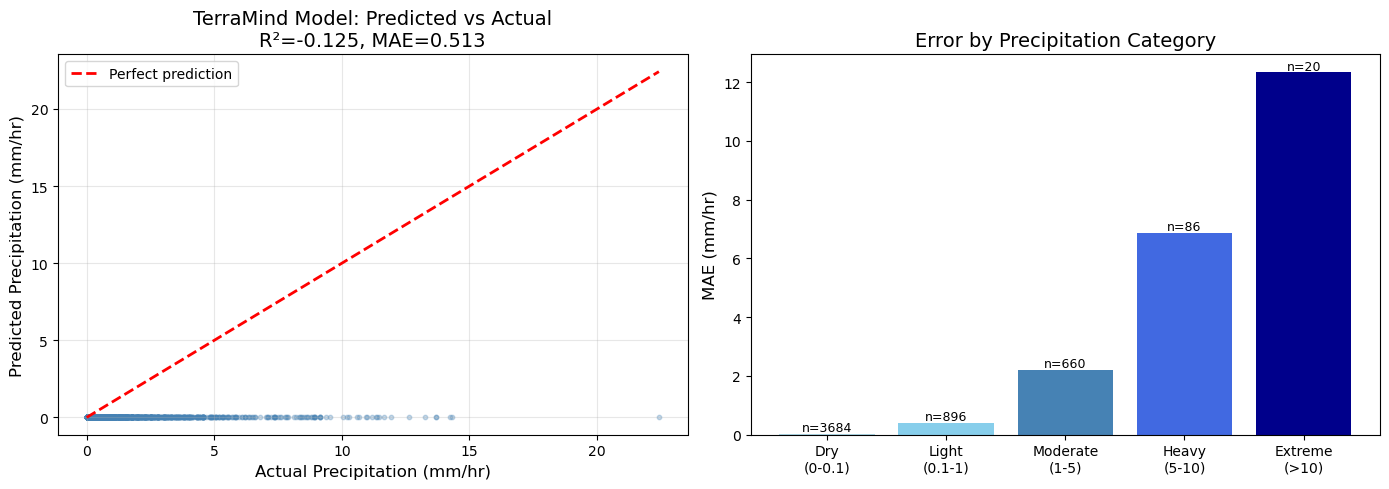


📊 COMPARE TO YOUR BEST STACKED MODEL:
  Stacked Model R²: 0.328
  TerraMind R²:     -0.125

  Stacked Model MAE: ~0.5 mm/hr
  TerraMind MAE:     0.513 mm/hr

  Stacked Pred Max: 8.19 mm/hr
  TerraMind Pred Max: 0.05 mm/hr


In [44]:
# ============================================================
# POST-TRAINING EVALUATION
# ============================================================
import matplotlib.pyplot as plt
from scipy import stats

# Reload data module if needed
dm = PickleDataModule('./radar_gauge_dataset_76.pkl', batch_size=8)
dm.setup()


model = TerraMindRainModel(
        backbone_name='terramind_v1_tiny',
        grid_size=5,
        lr=1e-4
    )


# Move model to eval mode
model.eval()
model.to(device)

# Collect predictions
all_preds = []
all_targets = []

print("Running validation...")
with torch.no_grad():
    for batch in dm.val_dataloader():
        # Move to device
        batch_gpu = {
            'dem_patch': batch['dem_patch'].to(device),
            'radar_patch': batch['radar_patch'].to(device),
            'target': batch['target'].to(device)
        }
        
        pred = model(batch_gpu)  # (B, 5, 5)
        target = batch_gpu['target']  # (B,) scalar
        
        # Extract center prediction for scalar target
        center_pred = pred[:, 2, 2].cpu().numpy()
        target_np = target.cpu().numpy()
        
        all_preds.extend(center_pred)
        all_targets.extend(target_np)

preds = np.array(all_preds)
targets = np.array(all_targets)

# ============================================================
# METRICS
# ============================================================
print("\n" + "="*60)
print("📊 TERRAMIND MODEL RESULTS")
print("="*60)

mae = np.mean(np.abs(targets - preds))
rmse = np.sqrt(np.mean((targets - preds)**2))
r2 = 1 - np.sum((targets - preds)**2) / np.sum((targets - targets.mean())**2)
pearson_r, pearson_p = stats.pearsonr(targets, preds)
spearman_r, spearman_p = stats.spearmanr(targets, preds)

print(f"\n📈 PREDICTION STATS:")
print(f"  Pred Range: [{preds.min():.2f}, {preds.max():.2f}] mm/hr")
print(f"  Pred Mean:  {preds.mean():.3f} mm/hr")
print(f"  Target Range: [{targets.min():.2f}, {targets.max():.2f}] mm/hr")
print(f"  Target Mean:  {targets.mean():.3f} mm/hr")

print(f"\n🎯 METRICS:")
print(f"  MAE:        {mae:.3f} mm/hr")
print(f"  RMSE:       {rmse:.3f} mm/hr")
print(f"  R²:         {r2:.3f} ({r2*100:.1f}% variance explained)")
print(f"  Pearson r:  {pearson_r:.3f}")
print(f"  Spearman r: {spearman_r:.3f}")

# Count predictions above thresholds
print(f"\n📊 PREDICTIONS >5mm:  {np.sum(preds > 5)} / {len(preds)}")
print(f"📊 PREDICTIONS >10mm: {np.sum(preds > 10)} / {len(preds)}")
print(f"📊 ACTUAL >5mm:       {np.sum(targets > 5)} / {len(targets)}")
print(f"📊 ACTUAL >10mm:      {np.sum(targets > 10)} / {len(targets)}")

# ============================================================
# SCATTER PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(targets, preds, alpha=0.3, s=10, c='steelblue')
ax1.plot([0, max(targets.max(), preds.max())], [0, max(targets.max(), preds.max())], 
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Precipitation (mm/hr)', fontsize=12)
ax1.set_ylabel('Predicted Precipitation (mm/hr)', fontsize=12)
ax1.set_title(f'TerraMind Model: Predicted vs Actual\nR²={r2:.3f}, MAE={mae:.3f}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error by category
ax2 = axes[1]
categories = ['Dry\n(0-0.1)', 'Light\n(0.1-1)', 'Moderate\n(1-5)', 'Heavy\n(5-10)', 'Extreme\n(>10)']
bounds = [0, 0.1, 1, 5, 10, 100]
maes = []
counts = []

for i in range(len(bounds)-1):
    mask = (targets >= bounds[i]) & (targets < bounds[i+1])
    if mask.sum() > 0:
        maes.append(np.mean(np.abs(targets[mask] - preds[mask])))
        counts.append(mask.sum())
    else:
        maes.append(0)
        counts.append(0)

bars = ax2.bar(categories, maes, color=['lightblue', 'skyblue', 'steelblue', 'royalblue', 'darkblue'])
ax2.set_ylabel('MAE (mm/hr)', fontsize=12)
ax2.set_title('Error by Precipitation Category', fontsize=14)

# Add count labels
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# COMPARISON TO STACKED MODEL
# ============================================================
print("\n" + "="*60)
print("📊 COMPARE TO YOUR BEST STACKED MODEL:")
print("="*60)
print(f"  Stacked Model R²: 0.328")
print(f"  TerraMind R²:     {r2:.3f}")
print(f"\n  Stacked Model MAE: ~0.5 mm/hr")
print(f"  TerraMind MAE:     {mae:.3f} mm/hr")
print(f"\n  Stacked Pred Max: 8.19 mm/hr")
print(f"  TerraMind Pred Max: {preds.max():.2f} mm/hr")